# はじめに

このノートではProphetライブラリをPythonで利用する方法をまとめておく。内容としては、時系列データの理解、ラグ特徴量を利用した特徴量エンジニアリング、クロスバリデーション、Optunaによるパラメタチューニング、将来の再帰予測までをまとめる。時系列分析に関する数理的な要素や分析の正当性については、ここでは扱わない。時系列分析で必要な観点において、一連で実行できるようにまとめる。

- [prophet](https://facebook.github.io/prophet/)

まずは使用するライブラリを読み込む。

In [1]:
# 0. ライブラリの読み込み
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from prophet import Prophet
from pmdarima.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import jpholiday

データは昔のブログのページビューの日次データで、GAからダウンロードした物を利用する。開設初期からのデータなので、不要な部分は予測のノイズになるので学習対象外にしている。

In [2]:
# 1. データの読み込み
df_all = pd.read_csv('./data/GoogleAnalytics_TimeSeriesData.csv')
df_all = df_all[['date', 'pageviews']].rename(columns={'date': 'ds', 'pageviews': 'y'})
df_all['ds'] = pd.to_datetime(df_all['ds'])
df = df_all[df_all['ds'] >= '2018-07-01'] # 予測精度を高めるために不要なレコードを削除

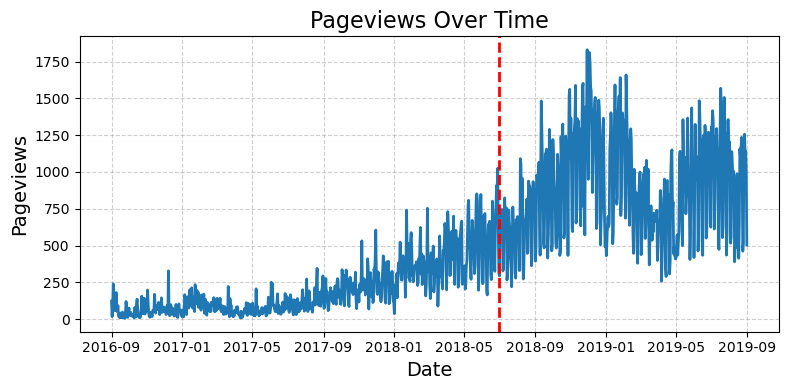

In [3]:
# 全データで可視化
plt.figure(figsize = (8, 4))
plt.plot(df_all['ds'], df_all['y'], linewidth = 2)
plt.axvline(pd.to_datetime('2018-07-01'), color='red', linestyle='--', linewidth=2, label='2018-07-01')
plt.title('Pageviews Over Time', fontsize = 16)
plt.xlabel('Date', fontsize = 14)
plt.ylabel('Pageviews', fontsize = 14)
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

上段の1階差分後のプロットをみると明確に7日ごとのスパイクが繰り返しているのがわかるので、週次の周期性をモデルに組み込む必要がある。

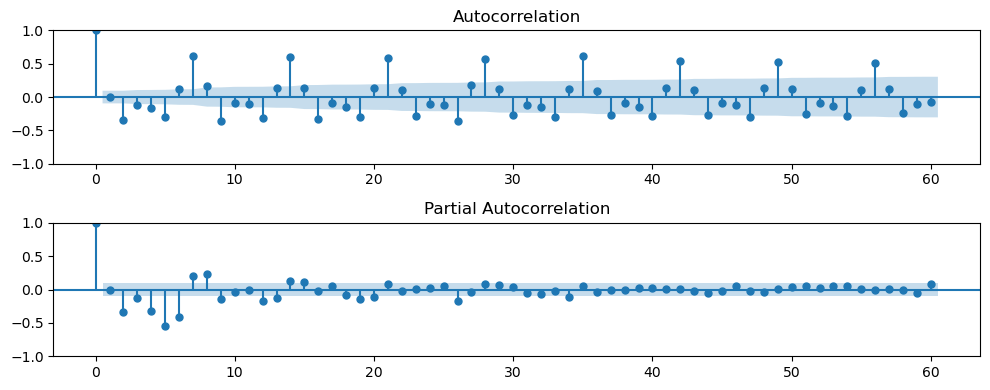

In [4]:
# 可視化 7日周期が確認できる
df_diff = df['y'].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize = (10, 4))
plot_acf(df_diff, lags = 60, ax = axes[0])
plot_pacf(df_diff, lags = 60, ax =axes[1])
plt.tight_layout()

1階差分＋7日差分後だと、7日ごとの周期スパイクが消え、PACFでも残っている自己相関は短期のわずかな依存だけであることがわかる。7日ラグや短期の特徴量は有効かもしれない。

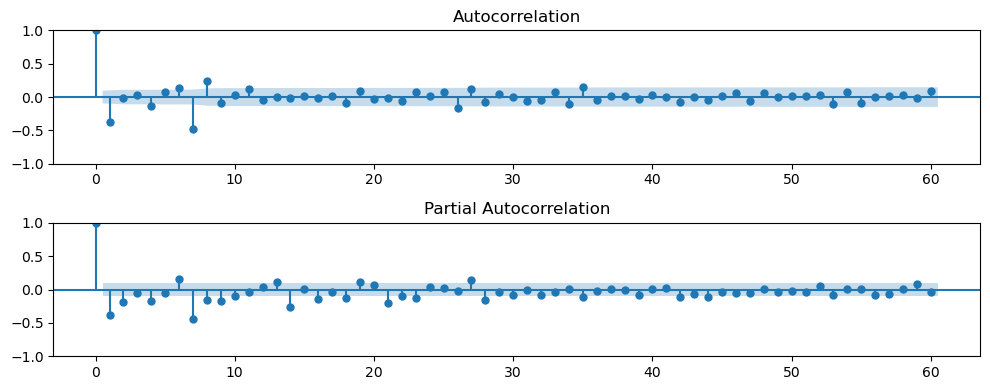

In [5]:
# 可視化 7日周期が確認できる
df_diff2 = df['y'].diff().diff(7).dropna()

fig, axes = plt.subplots(2, 1, figsize = (10, 4))
plot_acf(df_diff2, lags = 60, ax = axes[0])
plot_pacf(df_diff2, lags = 60, ax = axes[1])
plt.tight_layout()

## モデル構築
ここから予測モデルの作成を行っていく。ベースラインモデルでのテスト結果は末尾にまとめてある。ここでは7日先のデータを予測することを目標とする。

In [6]:
# 2. 未来分の空データを追加
future_dates = pd.date_range(df['ds'].max() + pd.Timedelta(days = 1), periods = 7)
forecast_df = pd.DataFrame({'ds': future_dates})
forecast_df['y'] = np.nan
# forecast_df

# 3. 学習と予測データを結合
full_df = pd.concat([df, forecast_df], ignore_index=True)

# 4. 特徴量の作成
# ラグ特徴量
lags = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
for lag in lags:
    full_df[f'lag{lag}'] = full_df['y'].shift(lag)

wins = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]  
for w in wins:
    full_df[f'win{w}'] = full_df['y'].shift(1).rolling(window=w, min_periods=1).mean()

expans = [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
for expan in expans:
    full_df[f'expan{expan}'] = full_df[f'lag{expan}'].expanding().mean()

# 曜日ダミー変数
full_df['weekday'] = full_df['ds'].dt.weekday
weekday_dummies = pd.get_dummies(full_df['weekday'], prefix='wd', drop_first=False)
full_df = pd.concat([full_df, weekday_dummies], axis=1)

# 火曜日のみダミー変数
full_df['is_tuesday'] = full_df['ds'].dt.weekday == 1

# 祝日ダミー変数
full_df['is_jholiday'] = full_df['ds'].apply(lambda x: jpholiday.is_holiday(x))

# 平均回帰を利用した特徴量    
# full_df['zlag1']  = full_df['lag1'] - full_df['win7']
# full_df['zlag7']  = full_df['lag7'] - full_df['win7']

# # 三角関数特徴量追加（日の周期性）
# full_df['dayofyear'] = full_df['ds'].dt.dayofyear
# full_df['sin_doy'] = np.sin(2 * np.pi * full_df['dayofyear'] / 365.25)
# full_df['cos_doy'] = np.cos(2 * np.pi * full_df['dayofyear'] / 365.25)

# モデルで利用するリグレッサを作成
regressors = (
    [f'lag{l}' for l in lags]
    + [f'win{l}' for l in wins]
    + [f'expan{l}' for l in expans]
    + [f'wd_{i}' for i in range(7)]
    + ['is_jholiday', 'is_tuesday']
    # + ['zlag1', 'zlag7', 'sin_doy', 'cos_doy']
)

full_df.tail(10)

,ds,y,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,...,weekday,wd_0,wd_1,wd_2,wd_3,wd_4,wd_5,wd_6,is_tuesday,is_jholiday
424,2019-08-29,1142.0,1133.0,1256.0,1184.0,517.0,462.0,1034.0,1235.0,746.0,...,3,False,False,False,True,False,False,False,False,False
425,2019-08-30,1004.0,1142.0,1133.0,1256.0,1184.0,517.0,462.0,1034.0,904.0,...,4,False,False,False,False,True,False,False,False,False
426,2019-08-31,504.0,1004.0,1142.0,1133.0,1256.0,1184.0,517.0,462.0,414.0,...,5,False,False,False,False,False,True,False,False,False
427,2019-09-01,NaN,504.0,1004.0,1142.0,1133.0,1256.0,1184.0,517.0,652.0,...,6,False,False,False,False,False,False,True,False,False
428,2019-09-02,NaN,NaN,504.0,1004.0,1142.0,1133.0,1256.0,1184.0,1157.0,...,0,True,False,False,False,False,False,False,False,False
429,2019-09-03,NaN,NaN,NaN,504.0,1004.0,1142.0,1133.0,1256.0,1098.0,...,1,False,True,False,False,False,False,False,True,False
430,2019-09-04,NaN,NaN,NaN,NaN,504.0,1004.0,1142.0,1133.0,1161.0,...,2,False,False,True,False,False,False,False,False,False
431,2019-09-05,NaN,NaN,NaN,NaN,NaN,504.0,1004.0,1142.0,1235.0,...,3,False,False,False,True,False,False,False,False,False
432,2019-09-06,NaN,NaN,NaN,NaN,NaN,NaN,504.0,1004.0,1034.0,...,4,False,False,False,False,True,False,False,False,False
433,2019-09-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,504.0,462.0,...,5,False,False,False,False,False,True,False,False,False


各目的に対するデータの分割は下記の通り。

- 学習データ: 2018-07-01 ~ 2019-06-30(学習と評価に分割し、クロスバリデーションを実行する)
- テストデータ: 2019-07-01 ~ 2019-08-31
- 予測データ: 2019-09-01

In [7]:
# 5. 学習(学習と評価)データとテストデータを作成
feature_cols = full_df.columns.difference(['ds']).tolist()
train_test_df = full_df[full_df[feature_cols].notna().all(axis = 1)].copy()
train_df, test_df = train_test_split(train_test_df, test_size = 62)

train_df['label'] = 'train'
test_df['label'] = 'test'

ハイパーパラメータチューニングを実施するために、Optunaに必要な情報を関数化する。Optunaを利用するからといえ、すべてのパラメタをとりあえずチューニングすると、テスト結果が散々になるので、必要なパラメタを前段階で見極めてからチューニングする必要がある。今回は、周期性はweeklyだけでよく、ほかを追加することで性能がすこぶる悪化した。

In [8]:
# 6. Optuna による Prophet ハイパーパラメータチューニング
def objective(trial, df = train_df):

    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 10),
        'weekly_fourier':          trial.suggest_int('weekly_fourier', 3, 7),
        'weekly_prior':            trial.suggest_float('weekly_prior', 1, 12),
        # 'seasonality_mode' :       trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative'])
        # 'changepoint_range':       trial.suggest_float('changepoint_range', 0.80, 0.95),
        # 'n_changepoints':          trial.suggest_int('n_changepoints', 10, 30),
        # 'yearly_fourier':          trial.suggest_int('yearly_fourier', 5, 15),
        # 'quaterly_fourier':        trial.suggest_int('quaterly_fourier', 3, 12),
        # 'monthly_fourier':         trial.suggest_int('monthly_fourier', 3, 12),
        # 'yearly_prior':            trial.suggest_float('yearly_prior', 1, 12),
        # 'quaterly_prior':          trial.suggest_float('quaterly_prior',1 , 12),
        # 'monthly_prior':           trial.suggest_float('monthly_prior', 1, 12),
    }
    
    cv_mae = []
    tss = TimeSeriesSplit(n_splits = 5)

    for fold, (train_index, valid_index) in enumerate(tss.split(df)):
        train_data = df.iloc[train_index].copy()
        valid_data = df.iloc[valid_index].copy()

        # モデル定義
        m = Prophet(
                changepoint_prior_scale = params['changepoint_prior_scale'],
                seasonality_prior_scale = params['seasonality_prior_scale'],
                yearly_seasonality = False,
                weekly_seasonality = False,
                daily_seasonality = False,
                growth = 'linear',
                seasonality_mode = 'additive' # params['seasonality_mode']
                # changepoint_range = params['changepoint_range'],
                # n_changepoints = params['n_changepoints'],
                )
        
        for reg in regressors:
            m.add_regressor(reg)
        
        m.add_seasonality(name = 'weekly', period = 7, fourier_order = params['weekly_fourier'],prior_scale = params['weekly_prior'])
        # m.add_seasonality(name = 'yearly', period = 365.25, fourier_order = params['yearly_fourier'],prior_scale = params['yearly_prior'])
        # m.add_seasonality(name = 'monthly', period = 30.5, fourier_order = params['monthly_fourier'],prior_scale = params['monthly_prior'])
        # m.add_seasonality(name = 'quaterly', period = 365.25/4, fourier_order = params['quaterly_fourier'],prior_scale = params['quaterly_prior'])
        
        m.fit(train_data)
        preds = m.predict(valid_data)
        
        merged = pd.merge(valid_data[['ds', 'y']], preds[['ds', 'yhat']], on = 'ds', how = 'inner')
        val_mae = mean_absolute_error(merged['y'], merged['yhat'])
        cv_mae.append(val_mae)

    mean_mae = np.mean(cv_mae)
    return mean_mae

# ハイパーパラメータチューニング
study = optuna.create_study(direction = 'minimize')
study.optimize(objective, n_trials = 1000, n_jobs = 4)
best_params = study.best_params

best_params

[I 2025-08-10 14:43:45,554] A new study created in memory with name: no-name-4db39025-6ef9-44ab-97c6-33e40d078c30
14:43:45 - cmdstanpy - INFO - Chain [1] start processing
14:43:45 - cmdstanpy - INFO - Chain [1] start processing
14:43:45 - cmdstanpy - INFO - Chain [1] start processing
14:43:45 - cmdstanpy - INFO - Chain [1] start processing
14:43:45 - cmdstanpy - INFO - Chain [1] done processing
14:43:46 - cmdstanpy - INFO - Chain [1] done processing
14:43:46 - cmdstanpy - INFO - Chain [1] done processing
14:43:46 - cmdstanpy - INFO - Chain [1] done processing
14:43:46 - cmdstanpy - INFO - Chain [1] start processing
14:43:46 - cmdstanpy - INFO - Chain [1] start processing
14:43:46 - cmdstanpy - INFO - Chain [1] done processing
14:43:46 - cmdstanpy - INFO - Chain [1] done processing
14:43:46 - cmdstanpy - INFO - Chain [1] start processing
14:43:46 - cmdstanpy - INFO - Chain [1] done processing
14:43:46 - cmdstanpy - INFO - Chain [1] start processing
14:43:46 - cmdstanpy - INFO - Chain [1

{'changepoint_prior_scale': 0.0214759058805124,
 'seasonality_prior_scale': 1.0508580710714743,
 'weekly_fourier': 7,
 'weekly_prior': 7.8720745991920245}

チューニングが完了し、ベストパラメータが決まったら、学習データのみを利用して、テストデータでモデルを評価する。学習データが訓練済みモデルを利用して、テストデータの予測値を予測する。MAEは113なので、ベースラインモデルの158より改善されていることがわかる。テストデータでの予測は再帰予測する必要がないため、この後の再帰予測とは少し異なる。この点があるため、将来予測については甘め判定をしているとも言えなくないため、もし必要なのであれば、ここでの予測値も`y`をないものと考えて再帰予測する必要がある。

14:58:04 - cmdstanpy - INFO - Chain [1] start processing
14:58:04 - cmdstanpy - INFO - Chain [1] done processing


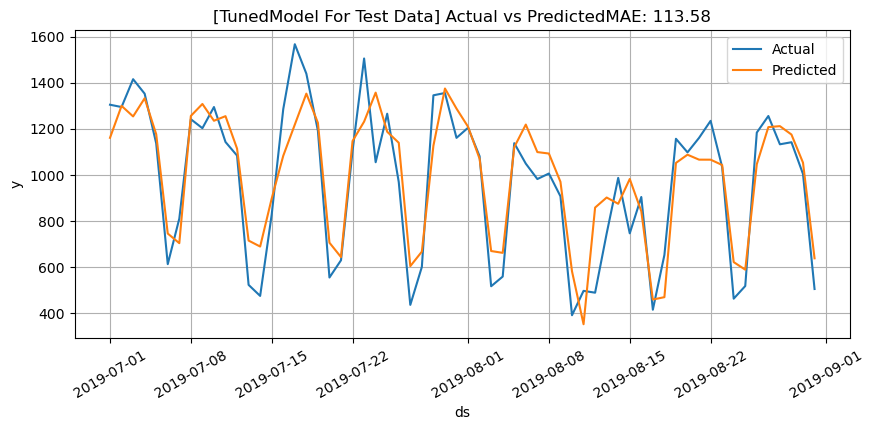

In [9]:
# チューニングされたパラメタ best_params
# {'changepoint_prior_scale': 0.026818359762607494,
#  'seasonality_prior_scale': 3.409417364298931,
#  'weekly_fourier': 3,
#  'weekly_prior': 8.24769314706872}

# 7. テストデータの評価をするためにチューニングされたパラメタでモデル構築
valid_model = Prophet(
        # changepoint_range = study.best_params['changepoint_range'],
        # n_changepoints=study.best_params['n_changepoints'],
        seasonality_prior_scale = study.best_params['seasonality_prior_scale'],
        changepoint_prior_scale = study.best_params['changepoint_prior_scale'],
        yearly_seasonality = False,
        weekly_seasonality = False,
        daily_seasonality  = False,
        growth = 'linear',
        seasonality_mode = 'additive' # study.best_params['seasonality_mode']
        )

for reg in regressors:
    valid_model.add_regressor(reg)
    
valid_model.add_seasonality(name = 'weekly', period = 7, fourier_order = study.best_params['weekly_fourier'],prior_scale = study.best_params['weekly_prior'])
# valid_model.add_seasonality(name = 'yearly', period = 365.25, fourier_order = study.best_params['yearly_fourier'],prior_scale = study.best_params['yearly_prior'])
# valid_model.add_seasonality(name = 'monthly', period = 30.5, fourier_order = study.best_params['monthly_fourier'],prior_scale = study.best_params['monthly_prior'])
# valid_model.add_seasonality(name = 'quaterly', period = 365.25/4, fourier_order = study.best_params['quaterly_fourier'],prior_scale = study.best_params['quaterly_prior'])

# 学習データでモデルを構築
valid_model.fit(train_df)

# モデル構造の可視化
# valid_model.plot_components(pd.concat([valid_model.predict(train_df), valid_model.predict(test_df)], ignore_index=True))
# fig = valid_model.plot_components(valid_model.predict(train_df))
# fig.show()

# テストデータの予測
pred = valid_model.predict(test_df)

# テストデータの評価
mae = mean_absolute_error(
    test_df[['y']], 
    pred[['yhat']]
    )

tmp = pd.merge(
    test_df[['ds', 'y']],
    pred[['ds', 'yhat']],
    on='ds',
    how='inner'
).sort_values('ds')

plt.figure(figsize=(10,4))
plt.plot(tmp['ds'], tmp['y'], label='Actual')
plt.plot(tmp['ds'], tmp['yhat'], label='Predicted')
plt.title(f'[TunedModel For Test Data] Actual vs Predicted' + f'MAE: {mae:.2f}')
plt.xlabel('ds')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.xticks(rotation=30)
plt.show()

テストデータを使った予測がベースラインを大きく下回っていたので、一旦、ここでモデル構築は完了し、予測の作業に移る。そのため、まずは学習データとテストデータをあわせたデータでモデルをフィッティングする。`y`を見るとわかるが、`NaN`になっている部分を1行づつ予測し、予測モデルが予測した`yhat`をもとにラグ特徴量を作り直して、予測することを再帰することで予測していく。

In [10]:
full_model = Prophet(
        # changepoint_range = study.best_params['changepoint_range'],
        # n_changepoints = study.best_params['n_changepoints'],
        seasonality_prior_scale = study.best_params['seasonality_prior_scale'],
        changepoint_prior_scale = study.best_params['changepoint_prior_scale'],
        yearly_seasonality = False,
        weekly_seasonality = False,
        daily_seasonality = False,
        growth = 'linear',
        seasonality_mode = 'additive'
        )

for reg in regressors:
    full_model.add_regressor(reg)
    
full_model.add_seasonality(name = 'weekly', period = 7, fourier_order = study.best_params['weekly_fourier'],prior_scale = study.best_params['weekly_prior'])
# full_model.add_seasonality(name = 'yearly', period = 365.25, fourier_order = study.best_params['yearly_fourier'],prior_scale = study.best_params['yearly_prior'])
# full_model.add_seasonality(name = 'monthly', period = 30.5, fourier_order = study.best_params['monthly_fourier'],prior_scale = study.best_params['monthly_prior'])
# full_model.add_seasonality(name = 'quaterly', period = 365.25/4, fourier_order = study.best_params['quaterly_fourier'],prior_scale = study.best_params['quaterly_prior'])

full_model.fit(train_test_df)
full_df.tail(10)

14:58:04 - cmdstanpy - INFO - Chain [1] start processing
14:58:05 - cmdstanpy - INFO - Chain [1] done processing


,ds,y,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,...,weekday,wd_0,wd_1,wd_2,wd_3,wd_4,wd_5,wd_6,is_tuesday,is_jholiday
424,2019-08-29,1142.0,1133.0,1256.0,1184.0,517.0,462.0,1034.0,1235.0,746.0,...,3,False,False,False,True,False,False,False,False,False
425,2019-08-30,1004.0,1142.0,1133.0,1256.0,1184.0,517.0,462.0,1034.0,904.0,...,4,False,False,False,False,True,False,False,False,False
426,2019-08-31,504.0,1004.0,1142.0,1133.0,1256.0,1184.0,517.0,462.0,414.0,...,5,False,False,False,False,False,True,False,False,False
427,2019-09-01,NaN,504.0,1004.0,1142.0,1133.0,1256.0,1184.0,517.0,652.0,...,6,False,False,False,False,False,False,True,False,False
428,2019-09-02,NaN,NaN,504.0,1004.0,1142.0,1133.0,1256.0,1184.0,1157.0,...,0,True,False,False,False,False,False,False,False,False
429,2019-09-03,NaN,NaN,NaN,504.0,1004.0,1142.0,1133.0,1256.0,1098.0,...,1,False,True,False,False,False,False,False,True,False
430,2019-09-04,NaN,NaN,NaN,NaN,504.0,1004.0,1142.0,1133.0,1161.0,...,2,False,False,True,False,False,False,False,False,False
431,2019-09-05,NaN,NaN,NaN,NaN,NaN,504.0,1004.0,1142.0,1235.0,...,3,False,False,False,True,False,False,False,False,False
432,2019-09-06,NaN,NaN,NaN,NaN,NaN,NaN,504.0,1004.0,1034.0,...,4,False,False,False,False,True,False,False,False,False
433,2019-09-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,504.0,462.0,...,5,False,False,False,False,False,True,False,False,False


In [11]:
# 8. 再帰予測
future_index = full_df[full_df['y'].isna()].index
for i, idx in enumerate(future_index):
    # lag計算
    for lag in lags:
        src_idx = idx - lag
        if src_idx in full_df.index:
            if not np.isnan(full_df.at[src_idx, 'y']):
                # 実績値がある場合はそのまま使う
                full_df.at[idx, f'lag{lag}'] = full_df.at[src_idx, 'y']
            else:
                # 予測値をlagに使う（再帰予測）
                full_df.at[idx, f'lag{lag}'] = full_df.at[src_idx, 'yhat']

    # win計算
    for win in wins:
        lag_vals = []
        for k in range(win):
            lag_idx = idx - win + k + 1
            if lag_idx in full_df.index:
                yval = full_df.at[lag_idx, f'lag{win}']
                lag_vals.append(yval)
        if lag_vals:
            full_df.at[idx, f'win{win}'] = np.nanmean(lag_vals)
        else:
            full_df.at[idx, f'win{win}'] = np.nan

    # expan計算
    for expan in expans:
        expan_vals = []
        for k in range(0, idx):
            val = full_df.at[k, f'lag{expan}']
            if not np.isnan(val):
                expan_vals.append(val)
        if expan_vals:
            full_df.at[idx, f'expan{expan}'] = np.mean(expan_vals)
        else:
            full_df.at[idx, f'expan{expan}'] = np.nan

    # 予測
    input_row = full_df.loc[[idx], ['ds'] + feature_cols]
    pred = full_model.predict(input_row)
    yhat = pred['yhat'].values[0]
    yhat_lower = pred['yhat_lower'].values[0]
    yhat_upper = pred['yhat_upper'].values[0]
    full_df.at[idx, 'yhat'] = yhat
    full_df.at[idx, 'yhat_lower'] = yhat_lower
    full_df.at[idx, 'yhat_upper'] = yhat_upper
    # full_df.at[idx, 'y'] = y  # yはfuture_indexでは本来NaNのはずなので、ここでyを代入する必要はない


full_df.tail(10)

,ds,y,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag14,...,wd_2,wd_3,wd_4,wd_5,wd_6,is_tuesday,is_jholiday,yhat,yhat_lower,yhat_upper
424,2019-08-29,1142.0,1133.000000,1256.000000,1184.000000,517.000000,462.000000,1034.0000,1235.0,746.0,...,False,True,False,False,False,False,False,NaN,NaN,NaN
425,2019-08-30,1004.0,1142.000000,1133.000000,1256.000000,1184.000000,517.000000,462.0000,1034.0,904.0,...,False,False,True,False,False,False,False,NaN,NaN,NaN
426,2019-08-31,504.0,1004.000000,1142.000000,1133.000000,1256.000000,1184.000000,517.0000,462.0,414.0,...,False,False,False,True,False,False,False,NaN,NaN,NaN
427,2019-09-01,NaN,504.000000,1004.000000,1142.000000,1133.000000,1256.000000,1184.0000,517.0,652.0,...,False,False,False,False,True,False,False,584.917100,382.254766,773.685328
428,2019-09-02,NaN,584.917100,504.000000,1004.000000,1142.000000,1133.000000,1256.0000,1184.0,1157.0,...,False,False,False,False,False,False,False,1090.600188,881.199331,1306.204165
429,2019-09-03,NaN,1090.600188,584.917100,504.000000,1004.000000,1142.000000,1133.0000,1256.0,1098.0,...,False,False,False,False,False,True,False,1138.767759,939.772419,1351.432307
430,2019-09-04,NaN,1138.767759,1090.600188,584.917100,504.000000,1004.000000,1142.0000,1133.0,1161.0,...,True,False,False,False,False,False,False,1079.762186,869.213131,1303.192922
431,2019-09-05,NaN,1079.762186,1138.767759,1090.600188,584.917100,504.000000,1004.0000,1142.0,1235.0,...,False,True,False,False,False,False,False,1089.197113,882.267399,1290.514750
432,2019-09-06,NaN,1089.197113,1079.762186,1138.767759,1090.600188,584.917100,504.0000,1004.0,1034.0,...,False,False,True,False,False,False,False,991.768112,789.860119,1199.322222
433,2019-09-07,NaN,991.768112,1089.197113,1079.762186,1138.767759,1090.600188,584.9171,504.0,462.0,...,False,False,False,True,False,False,False,575.188707,389.505389,791.655016


In [12]:
# Debugの様子を可視化したもので。予測するレコードのインデックスを基準を参考にラグの数値分、レコードを遡ってラグの値を取得する。
# 例....
# i=0, idx=911
#   lag=1
#     src_idx = idx - lag
#     910     = 911 - 1
#     if src_idx in full_df.index:
#     if 910 in 0-918:
#       full_df.at[idx, f'lag{lag}'] = full_df.at[src_idx, 'y']
#       full_df.at[911, f'lag{1}'] = full_df.at[910, 'y']
# i=0, idx=911
#   lag=3
#     src_idx = idx - lag
#     908     = 911 - 3
#     if src_idx in full_df.index:
#     if 908 in 0-918:
#       full_df.at[idx, f'lag{lag}'] = full_df.at[src_idx, 'y']
#       full_df.at[911, f'lag{3}'] = full_df.at[908, 'y']

# i=1, idx=912
#   lag=1
#     src_idx = idx - lag
#     911     = 912 - 1
#     if src_idx in full_df.index:
#     if 911 in 0-918:
#       full_df.at[idx, f'lag{lag}'] = full_df.at[src_idx, 'y']
#       full_df.at[912, f'lag{3}'] = full_df.at[911, 'y']

予測結果をまとめ、可視化しやすいように整形しておく。ここでは直近100レコードを対象にする。

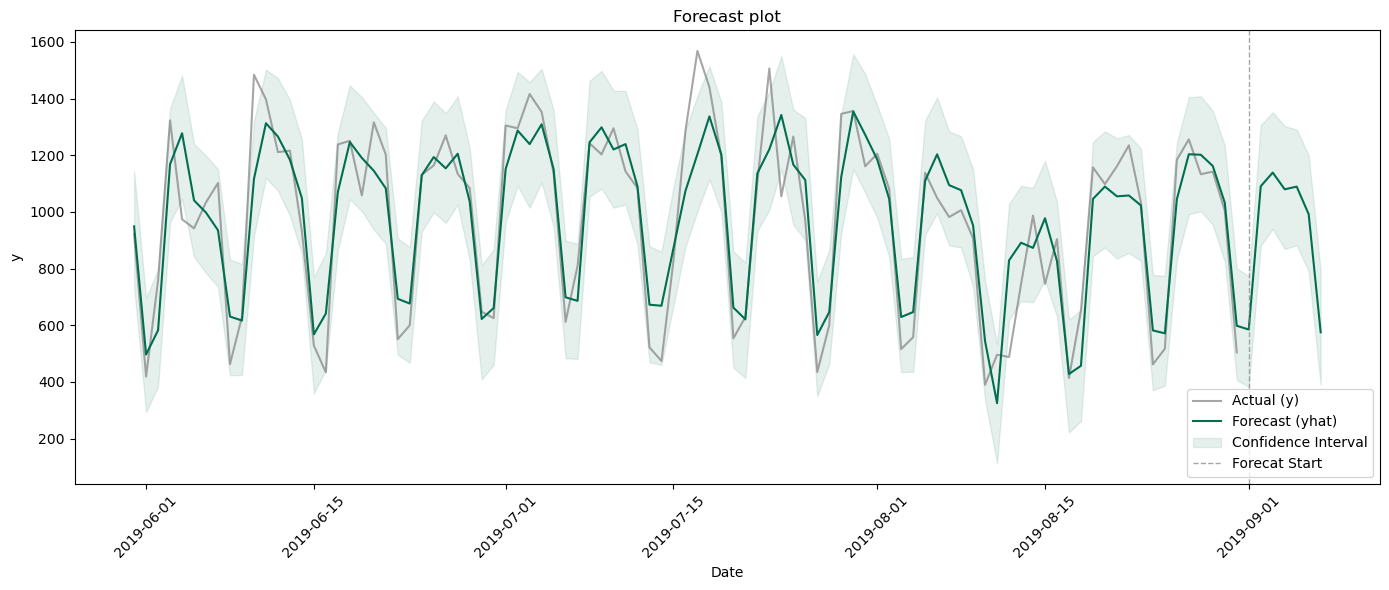

In [13]:
# 9. 予測結果をまとめる
pred_train_df = train_df.merge(full_model.predict(train_df), on='ds', how='left')[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'label']]
pred_test_df = test_df.merge(full_model.predict(test_df), on='ds', how='left')[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'label']]
pred_forecast_df = full_df.loc[future_index, ['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']]
pred_forecast_df['label'] = 'forecast'

# 全て結合
concat_df = pd.concat([pred_train_df, pred_test_df, pred_forecast_df])

# 10. 予測結果を可視化
last_df = concat_df.tail(100)
plt.figure(figsize = (14, 6))
plt.plot(last_df['ds'], last_df['y']   , label = 'Actual (y)'     , color = 'gray', alpha = 0.7)
plt.plot(last_df['ds'], last_df['yhat'], label = 'Forecast (yhat)', color = '#006E4F')
plt.fill_between(
    last_df['ds'],
    last_df['yhat_lower'],
    last_df['yhat_upper'],
    color = '#006E4F',
    alpha = 0.1,
    label = 'Confidence Interval'
)
plt.xlabel('Date')
plt.ylabel('y')
plt.title('Forecast plot')
plt.axvline(pd.to_datetime('2019-09-01'), color = 'gray',  alpha = 0.7, linestyle = '--', linewidth = 1, label = 'Forecat Start')
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# plotly
# import plotly.graph_objs as go
# import prophet.plot
# from prophet.plot import plot_plotly, plot_components_plotly
# import plotly.offline as py

# py.init_notebook_mode()
# fig = plot_plotly(full_model, concat_df)
# py.iplot(fig)

## ベースラインモデル

14:58:05 - cmdstanpy - INFO - Chain [1] start processing
14:58:05 - cmdstanpy - INFO - Chain [1] done processing


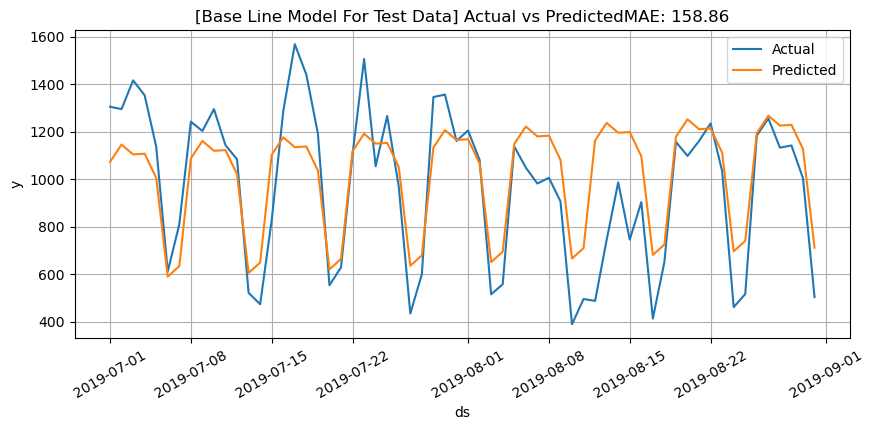

In [14]:
# ベースラインモデルを作成
base_model = Prophet(
  growth='linear',
  seasonality_mode='additive',
  yearly_seasonality=False,
  weekly_seasonality=True,
  daily_seasonality=False,
)
base_model.fit(train_df)
base_preds = base_model.predict(test_df)
mae = mean_absolute_error(test_df['y'], base_preds['yhat'])
base_plt = test_df.merge(base_preds, on='ds', how='left')[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']]

plt.figure(figsize=(10,4))
plt.plot(base_plt['ds'], base_plt['y'], label='Actual')
plt.plot(base_plt['ds'], base_plt['yhat'], label='Predicted')
plt.title(f'[Base Line Model For Test Data] Actual vs Predicted' + f'MAE: {mae:.2f}')
plt.xlabel('ds')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.xticks(rotation=30)
plt.show()